### Problem Statement

#### Analyze the growth and adoption of Internet usage across different countries from 2000 to 2023, identify countries and regions with high or low Internet penetration, understand historical trends, and use the available historical data to predict or estimate future Internet usage.

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv(r"C:\Users\dssas\OneDrive\Desktop\DS\Assignments\DB Scan\internet_usage.csv")
df.head(5)

,Country Name,Country Code,2000,2001,2002,2003,2004,2005,2006,2007,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,Afghanistan,AFG,..,0.00472257,0.0045614,0.0878913,0.105809,1.22415,2.10712,1.9,...,7,8.26,11,13.5,16.8,17.6,18.4,..,..,..
1,Albania,ALB,0.114097,0.325798,0.390081,0.9719,2.42039,6.04389,9.60999,15.0361,...,54.3,56.9,59.6,62.4,65.4,68.5504,72.2377,79.3237,82.6137,83.1356
2,Algeria,DZA,0.491706,0.646114,1.59164,2.19536,4.63448,5.84394,7.37598,9.45119,...,29.5,38.2,42.9455,47.6911,49.0385,58.9776,60.6534,66.2356,71.2432,..
3,American Samoa,ASM,..,..,..,..,..,..,..,..,...,..,..,..,..,..,..,..,..,..,..
4,Andorra,AND,10.5388,..,11.2605,13.5464,26.838,37.6058,48.9368,70.87,...,86.1,87.9,89.7,91.5675,..,90.7187,93.2056,93.8975,94.4855,..


### Understand the Dataset

In [3]:
df.shape

(217, 26)

In [4]:
df.describe()

,Country Name,Country Code,2000,2001,2002,2003,2004,2005,2006,2007,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
count,217,217,217,217,217,217,217,217,217,217,...,217,217,217,217,217,217,217,217,217,217
unique,217,217,197,200,202,196,198,199,199,197,...,194,196,199,203,175,183,191,185,178,58
top,Afghanistan,AFG,..,..,..,..,..,..,..,..,...,..,..,..,..,..,..,..,..,..,..
freq,1,1,21,18,15,21,18,17,18,13,...,16,17,14,11,41,31,25,27,34,158


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217 entries, 0 to 216
Data columns (total 26 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Country Name  217 non-null    object
 1   Country Code  217 non-null    object
 2   2000          217 non-null    object
 3   2001          217 non-null    object
 4   2002          217 non-null    object
 5   2003          217 non-null    object
 6   2004          217 non-null    object
 7   2005          217 non-null    object
 8   2006          217 non-null    object
 9   2007          217 non-null    object
 10  2008          217 non-null    object
 11  2009          217 non-null    object
 12  2010          217 non-null    object
 13  2011          217 non-null    object
 14  2012          217 non-null    object
 15  2013          217 non-null    object
 16  2014          217 non-null    object
 17  2015          217 non-null    object
 18  2016          217 non-null    object
 19  2017    

### EDA

In [6]:
df.isna().sum()

Country Name    0
Country Code    0
2000            0
2001            0
2002            0
2003            0
2004            0
2005            0
2006            0
2007            0
2008            0
2009            0
2010            0
2011            0
2012            0
2013            0
2014            0
2015            0
2016            0
2017            0
2018            0
2019            0
2020            0
2021            0
2022            0
2023            0
dtype: int64

In [7]:
df.replace(['!','@','#','$','',' ','*',0,'?','empty','..'],np.nan, inplace=True)

In [8]:
df.isna().sum()

Country Name      0
Country Code      0
2000             21
2001             18
2002             15
2003             21
2004             18
2005             17
2006             18
2007             13
2008             15
2009             15
2010             16
2011             13
2012             15
2013             16
2014             16
2015             17
2016             14
2017             11
2018             41
2019             31
2020             25
2021             27
2022             34
2023            158
dtype: int64

In [9]:
missing_values=(df.isna().sum()/len(df))*100
missing_values

Country Name     0.000000
Country Code     0.000000
2000             9.677419
2001             8.294931
2002             6.912442
2003             9.677419
2004             8.294931
2005             7.834101
2006             8.294931
2007             5.990783
2008             6.912442
2009             6.912442
2010             7.373272
2011             5.990783
2012             6.912442
2013             7.373272
2014             7.373272
2015             7.834101
2016             6.451613
2017             5.069124
2018            18.894009
2019            14.285714
2020            11.520737
2021            12.442396
2022            15.668203
2023            72.811060
dtype: float64

### Replacing the missing values

In [10]:
from sklearn.impute import SimpleImputer

si=SimpleImputer(strategy="most_frequent")

si.fit_transform(df.loc[:,'2000':'2022'])

array([['0', '0.00472257', '0.0045614', ..., '18.4', '100', '100'],
       ['0.114097', '0.325798', '0.390081', ..., '72.2377', '79.3237',
        '82.6137'],
       ['0.491706', '0.646114', '1.59164', ..., '60.6534', '66.2356',
        '71.2432'],
       ...,
       ['0.0825004', '0.0908025', '0.518796', ..., '13.8152', '14.8881',
        '17.6948'],
       ['0.191072', '0.23313', '0.477751', ..., '24.4992', '26.9505',
        '31.2342'],
       ['0.401434', '0.799846', '1.1', ..., '29.2986', '32.4616',
        '32.5615']], dtype=object)

In [11]:
df.loc[:,'2000':'2022'] = si.fit_transform(df.loc[:,'2000':'2022'])

### Delete unnecessary columns

In [12]:
df.drop(columns='2023', inplace=True)

In [13]:
df.isna().sum()

Country Name    0
Country Code    0
2000            0
2001            0
2002            0
2003            0
2004            0
2005            0
2006            0
2007            0
2008            0
2009            0
2010            0
2011            0
2012            0
2013            0
2014            0
2015            0
2016            0
2017            0
2018            0
2019            0
2020            0
2021            0
2022            0
dtype: int64

### Check the datatype of all the columns

In [14]:
df.dtypes

Country Name    object
Country Code    object
2000            object
2001            object
2002            object
2003            object
2004            object
2005            object
2006            object
2007            object
2008            object
2009            object
2010            object
2011            object
2012            object
2013            object
2014            object
2015            object
2016            object
2017            object
2018            object
2019            object
2020            object
2021            object
2022            object
dtype: object

### Change the datatype of columns having numeric values

In [15]:
for i in df.loc[:,'2000':]:
    df[i]=pd.to_numeric(df[i])

df.dtypes

Country Name     object
Country Code     object
2000            float64
2001            float64
2002            float64
2003            float64
2004            float64
2005            float64
2006            float64
2007            float64
2008            float64
2009            float64
2010            float64
2011            float64
2012            float64
2013            float64
2014            float64
2015            float64
2016            float64
2017            float64
2018            float64
2019            float64
2020            float64
2021            float64
2022            float64
dtype: object

### Drop unnecessary  columns

In [16]:
df.head(2)

,Country Name,Country Code,2000,2001,2002,2003,2004,2005,2006,2007,...,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
0,Afghanistan,AFG,0.000000,0.004723,0.004561,0.087891,0.105809,1.22415,2.10712,1.9000,...,5.9,7.0,8.26,11.0,13.5,16.8,17.6000,18.4000,100.0000,100.0000
1,Albania,ALB,0.114097,0.325798,0.390081,0.971900,2.420390,6.04389,9.60999,15.0361,...,51.8,54.3,56.90,59.6,62.4,65.4,68.5504,72.2377,79.3237,82.6137


In [17]:
df.drop(columns=['Country Name','Country Code'], inplace=True)

In [18]:
df.head(2)

,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
0,0.000000,0.004723,0.004561,0.087891,0.105809,1.22415,2.10712,1.9000,1.84,3.55,...,5.9,7.0,8.26,11.0,13.5,16.8,17.6000,18.4000,100.0000,100.0000
1,0.114097,0.325798,0.390081,0.971900,2.420390,6.04389,9.60999,15.0361,23.86,41.20,...,51.8,54.3,56.90,59.6,62.4,65.4,68.5504,72.2377,79.3237,82.6137


In [19]:
X=df.copy()
X.head(2)

,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
0,0.000000,0.004723,0.004561,0.087891,0.105809,1.22415,2.10712,1.9000,1.84,3.55,...,5.9,7.0,8.26,11.0,13.5,16.8,17.6000,18.4000,100.0000,100.0000
1,0.114097,0.325798,0.390081,0.971900,2.420390,6.04389,9.60999,15.0361,23.86,41.20,...,51.8,54.3,56.90,59.6,62.4,65.4,68.5504,72.2377,79.3237,82.6137


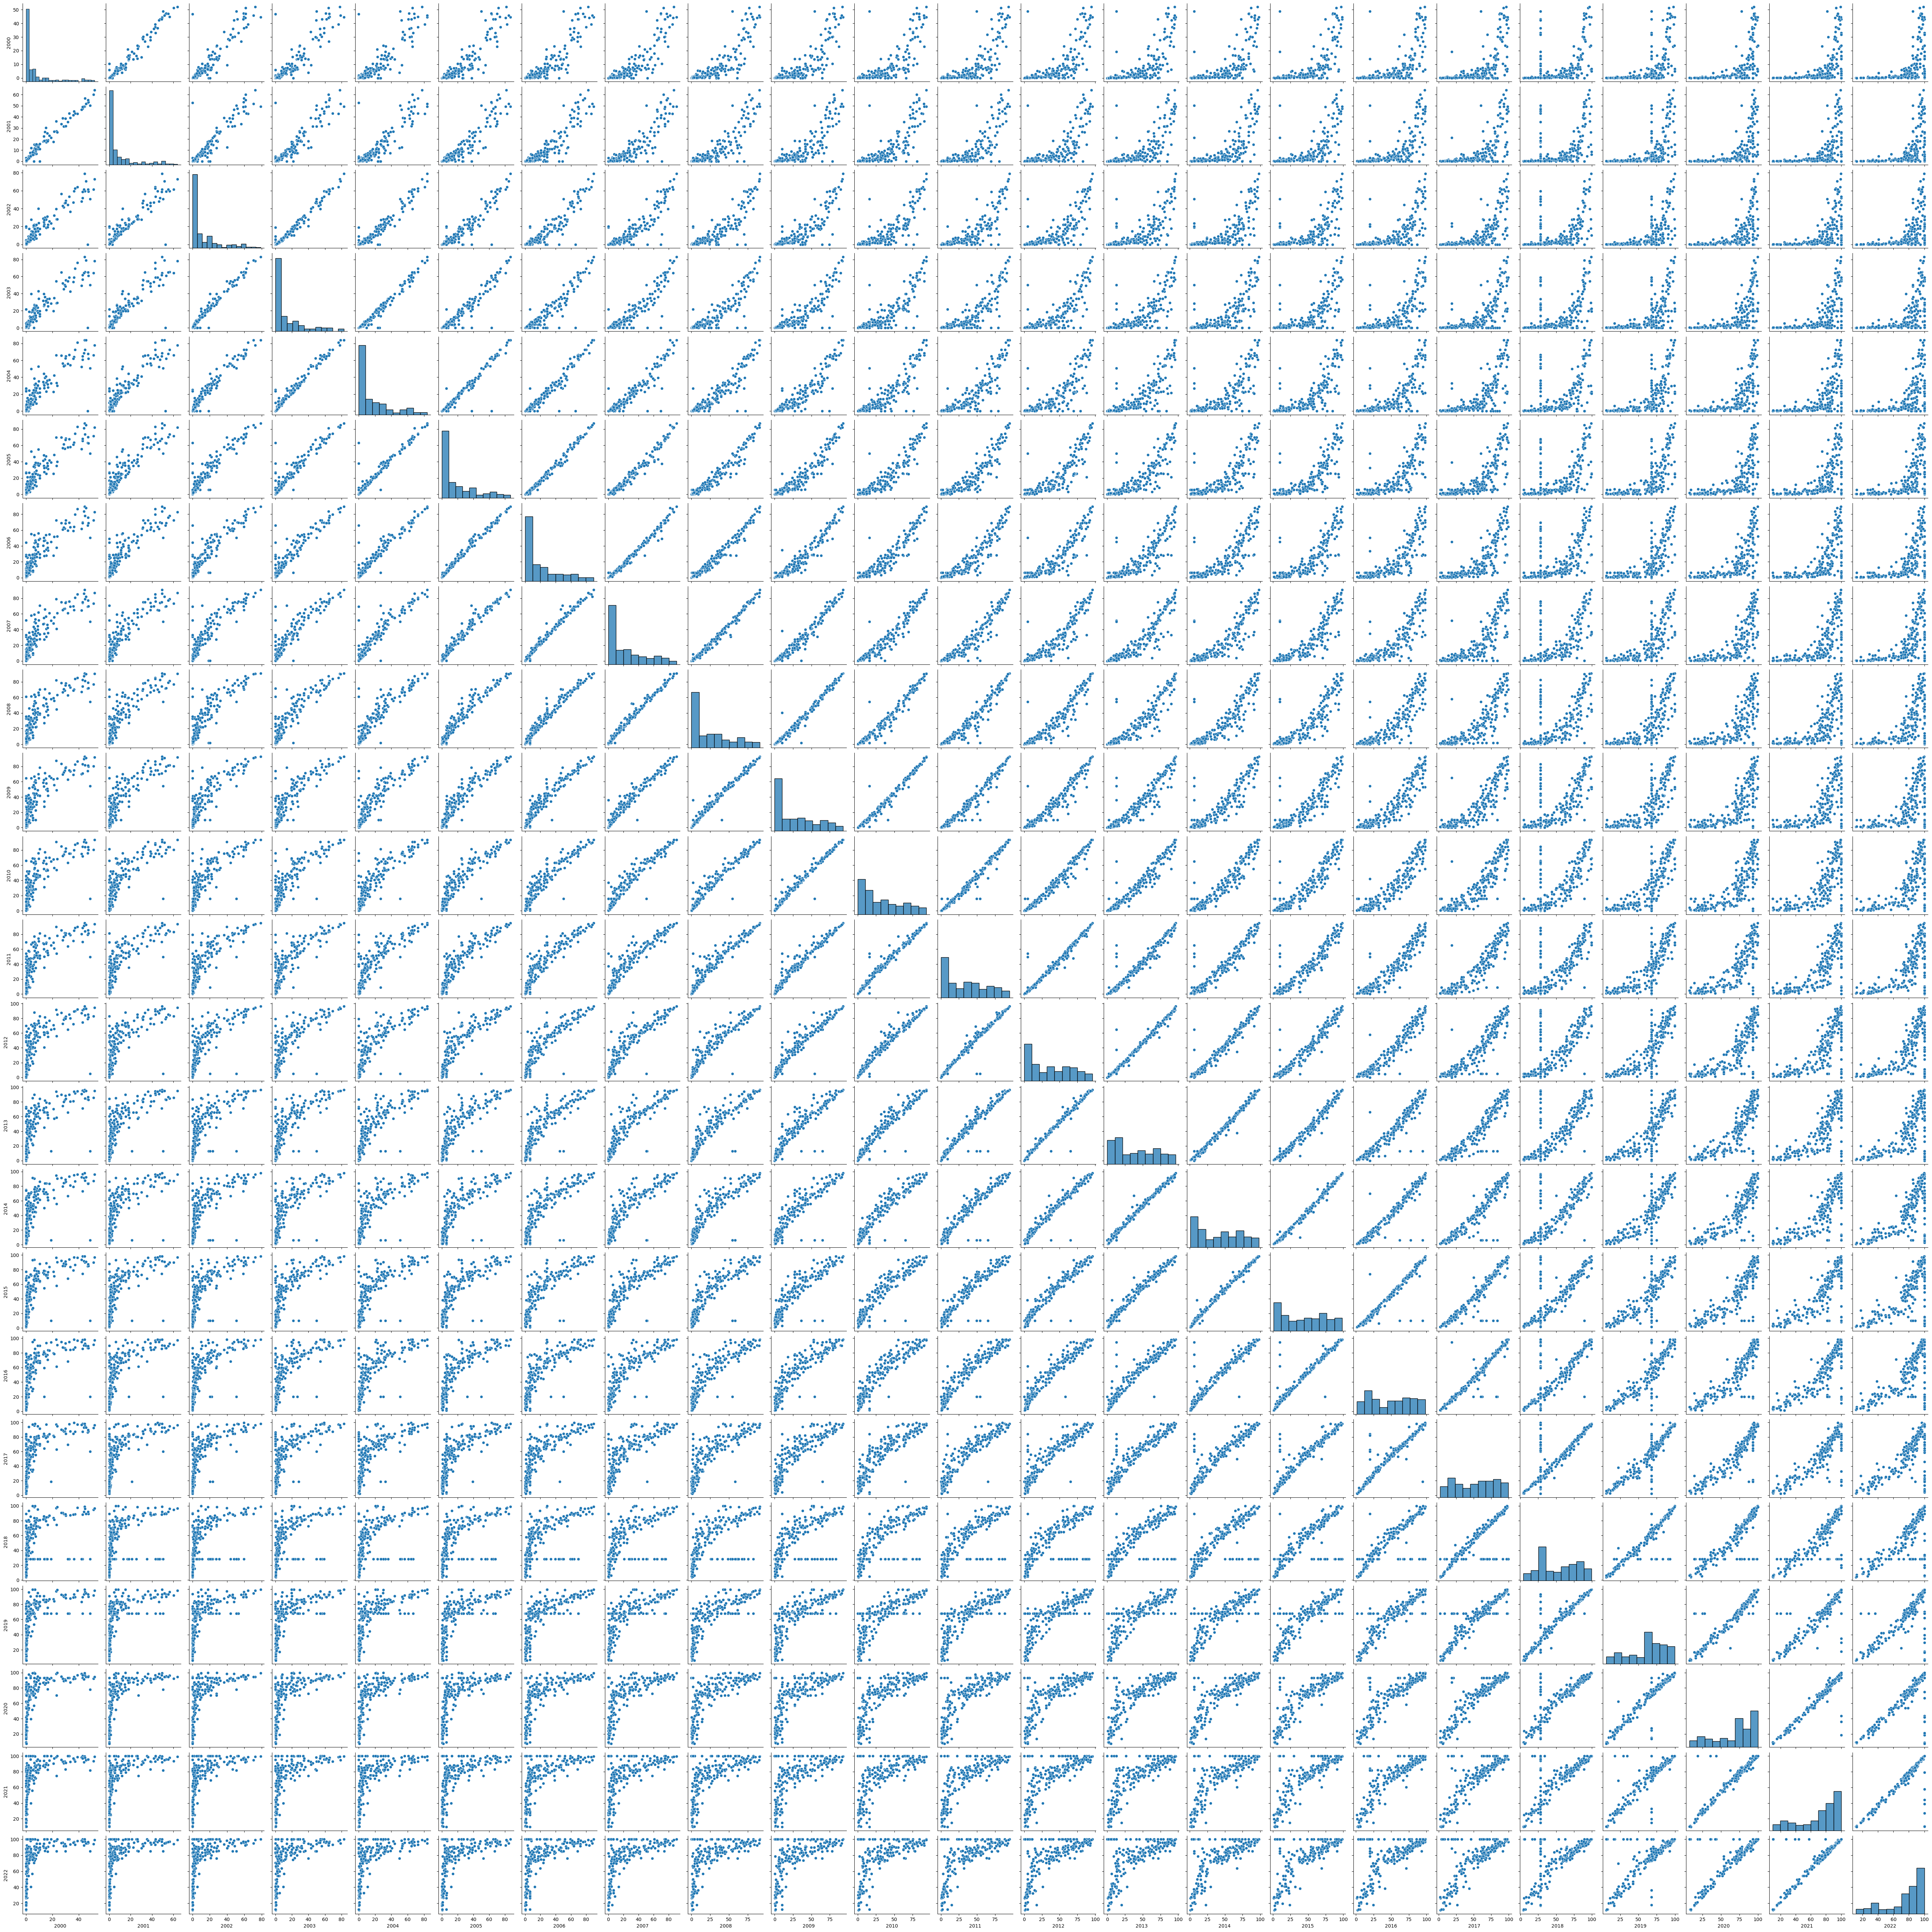

In [20]:
sns.pairplot(X)
plt.show()

### Scaling

#### DBSCAN is sensitive to feature scaling because it uses distance to determine neighboring points. Therefore, numerical features should generally be scaled before applying DBSCAN.

In [21]:
sc=StandardScaler()
X=sc.fit_transform(X)
X

array([[-0.61192595, -0.64778094, -0.70400051, ..., -1.88302986,
         1.07960244,  0.98549156],
       [-0.60307381, -0.62648264, -0.68258233, ...,  0.16914378,
         0.28586472,  0.27777184],
       [-0.5737773 , -0.60523471, -0.61582773, ..., -0.27242402,
        -0.21657134, -0.18507115],
       ...,
       [-0.60552521, -0.6420709 , -0.67543136, ..., -2.05779226,
        -2.18773869, -2.36479073],
       [-0.59710177, -0.63262971, -0.67771168, ..., -1.65054189,
        -1.72467799, -1.81366137],
       [-0.58078098, -0.59503701, -0.6431416 , ..., -1.46759941,
        -1.51311364, -1.75963284]])

### Train the model

In [22]:
db=DBSCAN()
ypred=db.fit_predict(X)
ypred

  File "C:\Users\dssas\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\dssas\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\dssas\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\dssas\anaconda3\Lib\subprocess.

array([-1, -1, -1,  0, -1,  2, -1, -1, -1, -1, -1, -1, -1, -1, -1,  2, -1,
       -1, -1, -1,  1, -1, -1, -1, -1, -1, -1, -1, -1, -1,  1, -1, -1, -1,
        2, -1, -1, -1, -1,  0, -1, -1, -1, -1,  1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,  1,  1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1,  0, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,  1, -1, -1, -1, -1, -1,  1,
        1, -1, -1,  1, -1, -1,  2, -1, -1, -1, -1, -1, -1, -1, -1,  1, -1,
       -1, -1,  2, -1, -1, -1, -1, -1, -1, -1,  0, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1,  1, -1, -1, -1, -1, -1, -1, -1,
        1, -1,  0, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,  0, -1, -1, -1,
       -1, -1, -1, -1,  1, -1, -1,  1, -1, -1, -1, -1, -1,  0, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,  1, -1])

In [23]:
silhouette_score(X, ypred)

np.float64(-0.037971231999066934)

### This is very close to 0 but slightly negative, which indicates that your clustering is poorly separated.
### The data points are not clearly grouped into distinct clusters. Many points may be closer to points in another cluster than to points in their own cluster.
### hyperparameter tuning is appropriate, especially because current Silhouette Score is -0.03797, which indicates weak clustering.

### Hyperparameter Tuning

In [25]:
neigh= NearestNeighbors(n_neighbors=3).fit(X)
neigh

NearestNeighbors(n_neighbors=3)

### Find the nearest neighbor for each data point

### Stores two outputs separately.dist Contains distances of nearest neighbors.index contains positions (row numbers) of nearest neighbors.

In [28]:
dist, index =neigh.kneighbors(X)

In [29]:
dist

array([[0.00000000e+00, 1.22588558e+00, 2.41342216e+00],
       [0.00000000e+00, 9.39956558e-01, 1.04265512e+00],
       [4.21468485e-08, 9.44694079e-01, 9.57984681e-01],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 2.55121213e+00, 2.73583190e+00],
       [0.00000000e+00, 3.51962565e-01, 4.67489581e-01],
       [0.00000000e+00, 7.59711922e-01, 8.74388561e-01],
       [0.00000000e+00, 8.67751489e-01, 9.80851901e-01],
       [4.21468485e-08, 6.63740901e-01, 9.29086699e-01],
       [0.00000000e+00, 2.16196479e+00, 2.60518756e+00],
       [1.68587394e-07, 3.91782096e+00, 4.15301139e+00],
       [1.19209290e-07, 8.05077528e-01, 9.73734554e-01],
       [8.42936970e-08, 1.07482547e+00, 1.13886346e+00],
       [5.96046448e-08, 1.21553967e+00, 1.38054229e+00],
       [0.00000000e+00, 1.22727196e+00, 1.38331371e+00],
       [0.00000000e+00, 4.28300154e-01, 4.98840957e-01],
       [0.00000000e+00, 1.49256248e+00, 1.63713052e+00],
       [0.00000000e+00, 9.78593

### Sorting in ascending order to find out the 3 nearest neighbors and get suitable graph

In [30]:
distance=np.sort(dist[:,2])
distance

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.2418238 , 0.28826947, 0.28826947,
       0.29136973, 0.29192381, 0.29648326, 0.29648326, 0.30350436,
       0.31052964, 0.36077657, 0.37559348, 0.41022594, 0.41881724,
       0.42830015, 0.43211372, 0.43432896, 0.44230917, 0.44230917,
       0.46748958, 0.49884096, 0.51131288, 0.51147847, 0.52640104,
       0.53144455, 0.54495308, 0.55838969, 0.55838969, 0.56028351,
       0.56233274, 0.56270101, 0.57029819, 0.57329529, 0.58477929,
       0.62160083, 0.6226344 , 0.63110314, 0.63283834, 0.63522642,
       0.64423664, 0.64470371, 0.65684427, 0.65738571, 0.66213535,
       0.6637409 , 0.66442192, 0.66518267, 0.67852261, 0.6800252 ,
       0.6800252 , 0.6837771 , 0.68471018, 0.68471018, 0.71175959,
       0.7142621 , 0.72490575, 0.73631622, 0.75130223, 0.75366404,
       0.75366404, 0.75603053, 0.76655015, 0.77581744, 0.77581744,
       0.78023498, 0.79746727, 0.7991866 , 0.80507753, 0.80599

### Make a graph to find correct epsilon value

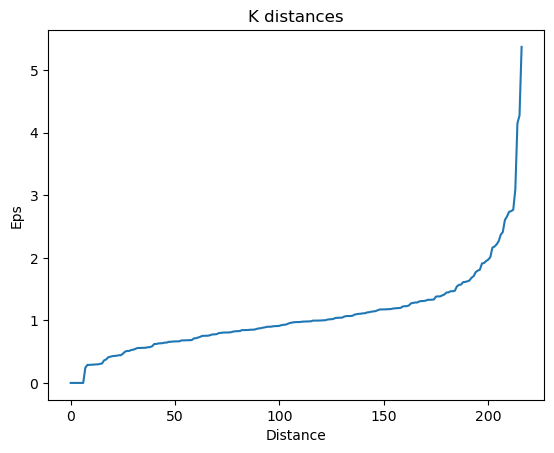

In [31]:
plt.plot(distance)
plt.xlabel("Distance")
plt.ylabel("Eps")
plt.title("K distances")
plt.show()

### Final Model

In [36]:
db= DBSCAN(eps= 2.5, min_samples=24)
ypred= db.fit_predict(X)

silhouette_score(X, ypred)

np.float64(0.39875892749223557)

### conclusion: A negative score initially suggested that the clusters were poorly separated. After tuning, the score became positive, meaning the resulting clusters have some meaningful separation and internal cohesion.